In [1]:
import numpy as np
from datetime import datetime 

import matplotlib.pyplot as plt
import xarray as xr
import rioxarray as rio
import seaborn as sns
sns.set_theme()
import pandas as pd
pd.set_option('display.precision', 2)

from pathlib import Path

import math
# import gcm

## 1. Load data

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
slc = xr.open_zarr(data_dir + 'stacks/slc_box_south_1x1')
slc = slc.sel(flight_id='27129')
print(slc)
# rmnp = xr.open_zarr(data_dir + 'stacks/rmnp_box_swe')

<xarray.Dataset> Size: 61MB
Dimensions:          (y: 616, x: 827, pol: 4, pair: 6)
Coordinates:
  * y                (y) float64 5kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 7kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair             (pair) <U13 312B '200213_200221' ... '210316_210322'
    band             int64 8B ...
    flight_id        <U5 20B '27129'
    spatial_ref      int64 8B ...
Data variables:
    canopy_2019      (y, x) float32 2MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    coherence        (pol, pair, y, x) float32 49MB dask.array<chunksize=(1, 2, 308, 414), meta=np.ndarray>
    cover_2019       (y, x) float64 4MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    elevation        (y, x) float32 2MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    incidence_angle  (y, x) float64 4MB dask.array<chunksize=(154, 414), meta=np.ndarray>


## 2. Filter data

Filter by: 
- Incidence angle < 80 degrees 
- Canopy cover < 30% 
- Elevation > the 20th quantile


In [3]:
inc_cutoff = 80
canopy_cutoff = 40
elev_quant = 60

In [4]:
def filter_data(data) : 
    single_year_pairs = [
        p for p in data.coords['pair'].values 
        if p[:2] == p[7:9]
    ]

    print(f'Filtering for {len(single_year_pairs)} single-year pairs.')
    data = data.sel(pair=single_year_pairs)

    print(f'Trimming to DEM.')
    data = data.where(data['elevation'].notnull())

    print(f'Filtering inc angle > {inc_cutoff}, canopy cover > {canopy_cutoff}, elev top {elev_quant}%.')
    condition = (data['incidence_angle'] < inc_cutoff) & \
                (data['canopy_2019'] < canopy_cutoff) & \
                (data['elevation'] > data['elevation'].quantile((100-elev_quant)/100))

    data = data.where(condition)

    return data
    

In [23]:
# rmnp_good = filter_data(rmnp)
slc_good = filter_data(filtered)
print(slc_good)

Filtering for 5 single-year pairs.
Trimming to DEM.
Filtering inc angle > 80, canopy cover > 40, elev top 60%.
<xarray.Dataset> Size: 53MB
Dimensions:          (y: 616, x: 827, pol: 4, pair: 5)
Coordinates:
  * y                (y) float64 5kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 7kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair             (pair) <U13 260B '210203_210210' ... '210316_210322'
    band             int64 8B ...
    flight_id        <U5 20B '27129'
    spatial_ref      int64 8B 0
    quantile         float64 8B 0.4
Data variables:
    canopy_2019      (y, x) float32 2MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    coherence        (pol, pair, y, x) float32 41MB dask.array<chunksize=(1, 2, 154, 414), meta=np.ndarray>
    cover_2019       (y, x) float64 4MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    elevation        (y, x) float32 2MB dask.array<chunksize=(154,

Show filters

In [6]:
filters_to_plot = slc 

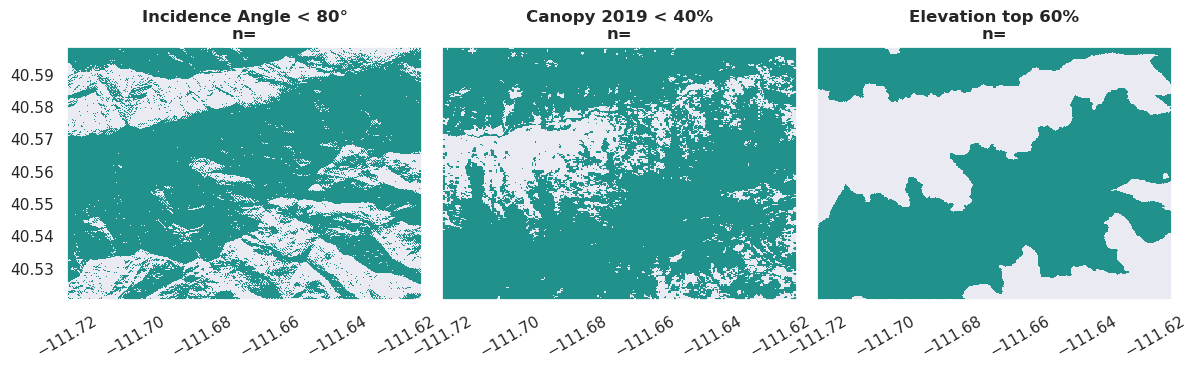

In [7]:
# show filters 

conditions = {
    f"Incidence Angle < {inc_cutoff}°": filters_to_plot['incidence_angle'] < inc_cutoff,
    f"Canopy 2019 < {canopy_cutoff}%": filters_to_plot['canopy_2019'] < canopy_cutoff,
    # "Cover 2019 (Shrubs)": (data['cover_2019'] > 50) & (data['cover_2019'] < 80),
    f"Elevation top {elev_quant}%": filters_to_plot['elevation'] > filters_to_plot['elevation'].quantile((100-elev_quant)/100)
}

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
axes = axes.ravel()  # Flatten the 2x2 grid into a 1D array for easy looping

# 3. Loop through and plot each isolated condition
for i, (title, cond) in enumerate(conditions.items()):
    ax = axes[i]
    
    # Use .where() to keep data where True, and set where False to NaN.
    # We can just plot 'cond' itself, or apply it to a variable like 'coherence'
    # if you want to see the underlying data values that passed.
    masked_slice = cond.where(cond) 
    
    # Squeeze out any extra dimensions (like band/time) if they exist
    masked_slice = masked_slice.squeeze()
    
    # Plot using xarray's native plotting wrapper, matching your style
    masked_slice.plot(
        ax=ax,
        cmap='viridis',     # Viridis will color the 'True' pixels
        add_colorbar=False
    )
    
    # Clean up the subplot
    ax.set_title(f'{title}\nn=', fontsize=12, fontweight='bold')
    ax.set_xlabel('')  # Remove repetitive x/y labels if sharing axes
    ax.set_ylabel('')

    ax.tick_params(axis='x', labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('center')

# Add a main title and clean up layout
# plt.suptitle("Valid pixels", 
#              fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [8]:
print(filtered)

NameError: name 'filtered' is not defined

## 3. Filter by cross-pol coherence

In [9]:
xpol_cutoff = 0.8

to_filter = slc 
print(to_filter)

<xarray.Dataset> Size: 61MB
Dimensions:          (y: 616, x: 827, pol: 4, pair: 6)
Coordinates:
  * y                (y) float64 5kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 7kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair             (pair) <U13 312B '200213_200221' ... '210316_210322'
    band             int64 8B ...
    flight_id        <U5 20B '27129'
    spatial_ref      int64 8B ...
Data variables:
    canopy_2019      (y, x) float32 2MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    coherence        (pol, pair, y, x) float32 49MB dask.array<chunksize=(1, 2, 308, 414), meta=np.ndarray>
    cover_2019       (y, x) float64 4MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    elevation        (y, x) float32 2MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    incidence_angle  (y, x) float64 4MB dask.array<chunksize=(154, 414), meta=np.ndarray>


In [10]:
coh_dir = Path(data_dir + "/uavsar_cohs_cropped/stlake/27129/")
print(coh_dir)

# Find all cross-pol files
file_paths = list(coh_dir.glob("*_crosspol_coh.tif"))
print(file_paths)

crosspol_lists = []
dates = []

for path in file_paths:
    # Example filename: stlake_27129_200131_HV-VH_s1_w5_crosspol_coh.tif
    # Split by underscore and grab the date string (index 2)
    date_str = path.name.split('_')[2] 
    
    # Open the TIFF and drop the single 'band' dimension to keep it 2D (y, x)
    da = rio.open_rasterio(path).squeeze('band', drop=True)
    
    crosspol_lists.append(da)
    dates.append(date_str)

# Combine all individual flight dates into a single DataArray
da_crosspol = xr.concat(crosspol_lists, dim='date')
da_crosspol = da_crosspol.rio.write_crs('EPSG:4326')
da_crosspol['date'] = dates
print(da_crosspol)

/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129
[PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210310_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_200221_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210210_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210223_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210316_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropped/stlake/27129/stlake_27129_210203_HV-VH_s1_w7x10_crosspol_coh.tif'), PosixPath('/bsuhome/julialober/scratch/coherence_data/uavsar_cohs_cropp

<xarray.DataArray (date: 11, y: 10228, x: 13734)> Size: 6GB
array([[[0.9977378 , 0.9980616 , 0.99562055, ..., 0.38521585,
         0.46561775, 0.5566377 ],
        [0.99742675, 0.99762356, 0.99460804, ..., 0.25938794,
         0.36998585, 0.509439  ],
        [0.9969099 , 0.9970023 , 0.9932262 , ..., 0.2293313 ,
         0.36015287, 0.5387213 ],
        ...,
        [0.45688227, 0.5222051 , 0.5749911 , ..., 0.48214117,
         0.5567095 , 0.56979483],
        [0.44314796, 0.51779467, 0.5758153 , ..., 0.4830612 ,
         0.5693189 , 0.5931806 ],
        [0.48439637, 0.5422848 , 0.5918    , ..., 0.4929016 ,
         0.5942362 , 0.6322062 ]],

       [[0.9557726 , 0.96933997, 0.97656006, ..., 0.52183396,
         0.6368283 , 0.74014145],
        [0.95721775, 0.96838844, 0.974784  , ..., 0.5279917 ,
         0.624872  , 0.7209005 ],
        [0.9565074 , 0.9654581 , 0.9717914 , ..., 0.45068416,
         0.50967914, 0.5913395 ],
...
         0.54074186, 0.5560923 ],
        [0.33433378, 0.

In [11]:
da_crosspol = da_crosspol.rio.reproject_match(to_filter)


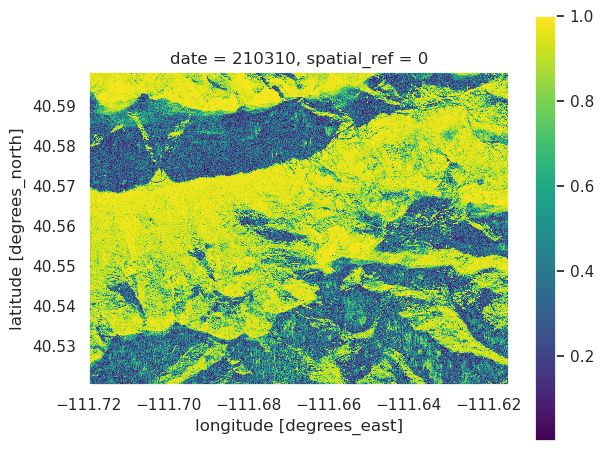

In [47]:
fig, ax = plt.subplots()
da_crosspol.sel(date='210310').plot(ax= ax)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

<xarray.DataArray (pair: 6, y: 616, x: 827)> Size: 12MB
array([[[0.9510576 , 0.9391688 , 0.9800755 , ..., 0.47585198,
         0.28718954, 0.62611246],
        [0.970596  , 0.97544146, 0.9794523 , ..., 0.2980539 ,
         0.45070332, 0.11704855],
        [0.9409401 , 0.9501686 , 0.9122884 , ..., 0.4371026 ,
         0.22800536, 0.09899592],
        ...,
        [0.2372122 , 0.36730722, 0.20765409, ..., 0.48330116,
         0.26383495, 0.04714717],
        [0.5920559 , 0.46495807, 0.18932743, ..., 0.11532272,
         0.3786098 , 0.6191092 ],
        [0.28827178, 0.37174654, 0.55079967, ..., 0.16301392,
         0.16005239, 0.39049748]],

       [[0.9589933 , 0.95066386, 0.9643329 , ..., 0.33423758,
         0.33393863, 0.23713732],
        [0.9514034 , 0.98605144, 0.9957825 , ..., 0.44822994,
         0.08780974, 0.26916984],
        [0.9800875 , 0.9856801 , 0.972343  , ..., 0.48251334,
         0.6438166 , 0.56808966],
...
        [0.6489097 , 0.15633902, 0.50632316, ..., 0.4434054 ,

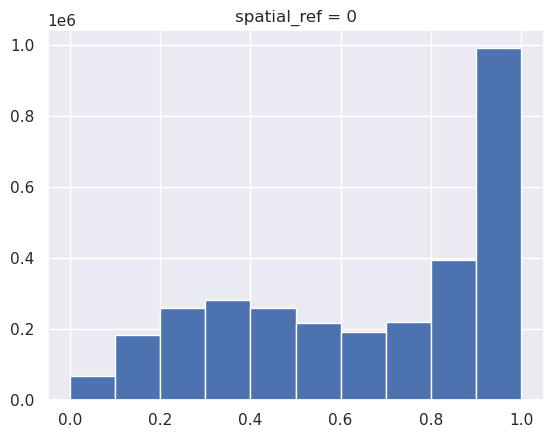

In [12]:
pair_names = to_filter['pair'].values
dates_1 = [p.split('_')[0] for p in pair_names]
dates_2 = [p.split('_')[1] for p in pair_names]

# 2. Use xarray's advanced indexing to pull the cross-pol data for all date1s and date2s.
# This creates 3D arrays (pair, y, x) matching your interferometric structure.
crosspol_date1 = da_crosspol.sel(date=xr.DataArray(dates_1, dims='pair', coords={'pair': pair_names}))
print(crosspol_date1)
crosspol_date2 = da_crosspol.sel(date=xr.DataArray(dates_2, dims='pair', coords={'pair': pair_names}))
crosspol_date2.plot()

# 3. Create a boolean mask where BOTH flights must be >= threshold
# (Pixels fail if either flight falls below the threshold)
crosspol_mask = ((crosspol_date1 >= xpol_cutoff) & (crosspol_date2 >= xpol_cutoff)).all(dim='pair')

# 4. Filter your existing dataset using the mask
filtered = to_filter.where(crosspol_mask)

In [13]:
filtered = filtered.sel(pair=['210203_210210', '210223_210303', '210303_210310', '210310_210316', '210316_210322'])

<xarray.DataArray 'coherence' (pol: 4, pair: 5, y: 616, x: 827)> Size: 41MB
dask.array<getitem, shape=(4, 5, 616, 827), dtype=float32, chunksize=(1, 2, 308, 414), chunktype=numpy.ndarray>
Coordinates:
  * pol          (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair         (pair) <U13 260B '210203_210210' ... '210316_210322'
  * y            (y) float64 5kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52 40.52
  * x            (x) float64 7kB -111.7 -111.7 -111.7 ... -111.6 -111.6 -111.6
    band         int64 8B ...
    flight_id    <U5 20B '27129'
    spatial_ref  int64 8B 0


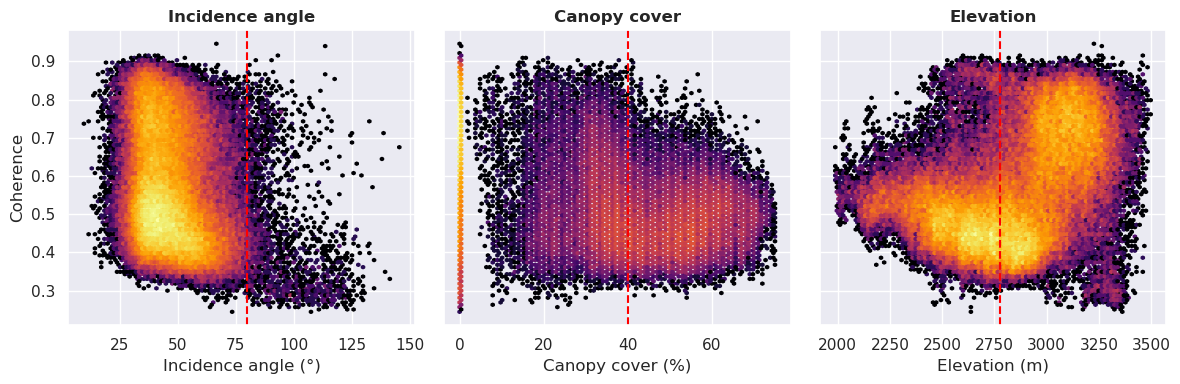

In [25]:
base = filtered

variables = {
    f"Incidence angle": "incidence_angle",
    f"Canopy cover": "canopy_2019",
    f"Elevation": "elevation",
}
labels = [
    "Incidence angle (°)",
    "Canopy cover (%)", 
    "Elevation (m)"
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
axes = axes.ravel()

print(base['coherence'])
y_full = base['coherence'].mean(dim=['pol', 'pair']).values.ravel()

for i, (title, var) in enumerate(variables.items()):
    ax = axes[i]

    x_full = base[var].values.ravel()
    if title == 'Canopy cover': 
        # x = base[var].where(base[var] > 0).values.ravel()
        cutoff = canopy_cutoff
    elif title == 'Incidence angle':
        cutoff = inc_cutoff
    else: 
        cutoff = base['elevation'].quantile((100-elev_quant)/100)

    mask = ~np.isnan(x_full) & ~np.isnan(y_full)
    x = x_full[mask]
    y = y_full[mask]
        
    # y = base['coherence'].mean(dim=['pair','pol']).values.ravel()

    
    # ax.scatter(
    #     x,
    #     y,
    #     marker='.',
    #     alpha=0.01
    # )

    ax.hexbin(
        x,
        y, 
        gridsize=100, 
        bins='log',
        cmap='inferno'
    )
    
    ax.axvline(
        cutoff,
        linestyle='--',
        c = 'red',
    )

    # Clean up the subplot
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{labels[i]}')  
    ax.set_ylabel('')

axes[0].set_ylabel('Coherence')
plt.tight_layout()
plt.show()

## 3. Visualize

In [26]:
to_plot = slc_good 
to_plot

<xarray.Dataset> Size: 53MB
Dimensions:          (y: 616, x: 827, pol: 4, pair: 5)
Coordinates:
  * y                (y) float64 5kB 40.6 40.6 40.6 40.6 ... 40.52 40.52 40.52
  * x                (x) float64 7kB -111.7 -111.7 -111.7 ... -111.6 -111.6
  * pol              (pol) <U2 32B 'VV' 'HH' 'VH' 'HV'
  * pair             (pair) <U13 260B '210203_210210' ... '210316_210322'
    band             int64 8B ...
    flight_id        <U5 20B '27129'
    spatial_ref      int64 8B 0
    quantile         float64 8B 0.4
Data variables:
    canopy_2019      (y, x) float32 2MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    coherence        (pol, pair, y, x) float32 41MB dask.array<chunksize=(1, 2, 154, 414), meta=np.ndarray>
    cover_2019       (y, x) float64 4MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    elevation        (y, x) float32 2MB dask.array<chunksize=(154, 414), meta=np.ndarray>
    incidence_angle  (y, x) float64 4MB dask.array<chunksize=(154, 414), meta=np.ndarray>

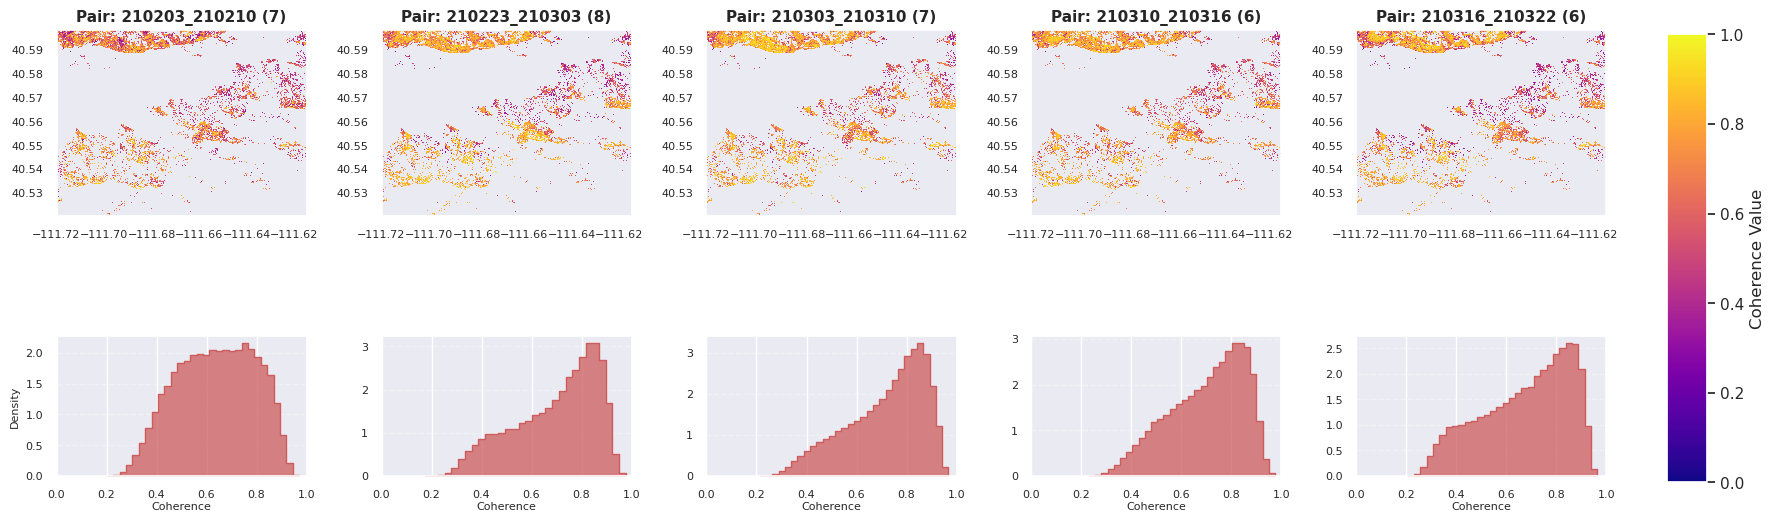

In [29]:
# plot 
ds_sorted = to_plot.sortby('pair')
pairs = ds_sorted.pair.values
num_pairs = len(pairs)

# 2. Configure the 5-column grid layout
ncols = 5
num_groups = (num_pairs + ncols - 1) // ncols
nrows = num_groups * 2 

# --- THE FIX: Create alternating height ratios (Map = 2, Hist = 1) ---
# For 3 groups (6 rows), this generates: [2, 1, 2, 1, 2, 1]
row_height_ratios = []
for _ in range(num_groups):
    row_height_ratios.extend([2, 1])

# Create the master canvas using the new height ratios
fig, axes = plt.subplots(
    nrows=nrows, 
    ncols=ncols, 
    figsize=(4 * ncols, 3.2 * nrows), # Slightly reduced multiplier to account for shorter hists
    gridspec_kw={
        'hspace': 0.35, 
        'wspace': 0.3,
        'height_ratios': row_height_ratios  # <-- Directly scales row heights
    }
)

# 3. Loop through every pair and assign them to the correct grid slots
for idx, pair_name in enumerate(pairs):
    col = idx % ncols
    group = idx // ncols
    row_map = group * 2
    row_hist = (group * 2) + 1
    
    ax_map = axes[row_map, col]
    ax_hist = axes[row_hist, col]
    
    # Extract the 2D spatial slice for this specific pair
    coh_slice = ds_sorted['coherence'].sel(pair=pair_name, pol='VV').squeeze()
    
    # --- TOP PLOT: Spatial Map ---
    coh_slice.plot(
        ax=ax_map, 
        cmap='plasma', 
        vmin=0, 
        vmax=1, 
        add_colorbar=False
    )
    t1, t2 = [datetime.strptime(d, "%y%m%d") for d in pair_name.split("_")]
    # Calculate the difference in days
    days_elapsed = (t2 - t1).days
    ax_map.set_title(f"Pair: {pair_name} ({days_elapsed})", fontsize=11, fontweight='bold')
    ax_map.set_xlabel("")
    ax_map.set_ylabel("")
    ax_map.tick_params(labelsize=8)
    ax_map.set_aspect('equal')
    
    # --- BOTTOM PLOT: Histogram (Half Height) ---
    flattened_vals = coh_slice.values.flatten()
    clean_vals = flattened_vals[~np.isnan(flattened_vals)]
    
    sns.histplot(
        clean_vals, 
        bins=30, 
        kde=False, 
        ax=ax_hist, 
        color='indianred', 
        element='step',
        stat='density'
    )
    ax_hist.set_xlim(0, 1)
    ax_hist.set_xlabel("Coherence", fontsize=8, labelpad=2)
    ax_hist.set_ylabel("Density" if col == 0 else "", fontsize=8)
    ax_hist.tick_params(labelsize=8)
    ax_hist.grid(axis='y', linestyle='--', alpha=0.3)

# 4. Clean up and delete any empty subplot slots in the final row group
for blank_idx in range(idx + 1, num_groups * ncols):
    b_col = blank_idx % ncols
    b_group = blank_idx // ncols
    
    fig.delaxes(axes[b_group * 2, b_col])     
    fig.delaxes(axes[(b_group * 2) + 1, b_col]) 

# 5. Add a single, unified colorbar on the right side of the entire figure
mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=0, vmax=1))
cbar_ax = fig.add_axes([0.93, 0.1, 0.02, 0.7]) 
fig.colorbar(mappable, cax=cbar_ax, label='Coherence Value')

plt.suptitle("", fontsize=16, fontweight='bold', y=0.99)
plt.show()